---
## **1. Introduction & Set Up**

#### **1.1. Import Necessary Libaries/Packages**

In [20]:
from sklearn.model_selection import train_test_split
import pandas as pd
import sys
from huggingface_hub import login
from datasets import load_dataset, DatasetDict, concatenate_datasets
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import os
import re

#### **1.2. Load Datasets**

In [9]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
val_df = pd.read_csv('val.csv')

#### **1.3. Label Mapping**

In [10]:
label_map = {'FAVOR': 0, 'NONE': 1, 'AGAINST': 2}

for df in [train_df, val_df, test_df]:
    df['label'] = df['Stance'].map(label_map)

print("Label distribution (train):")
print(train_df['Stance'].value_counts())

Label distribution (train):
Stance
AGAINST    1143
NONE        534
FAVOR       483
Name: count, dtype: int64


## **2. Exploratory Data Analysis**

#### **2.1. Class Distribution Plot**

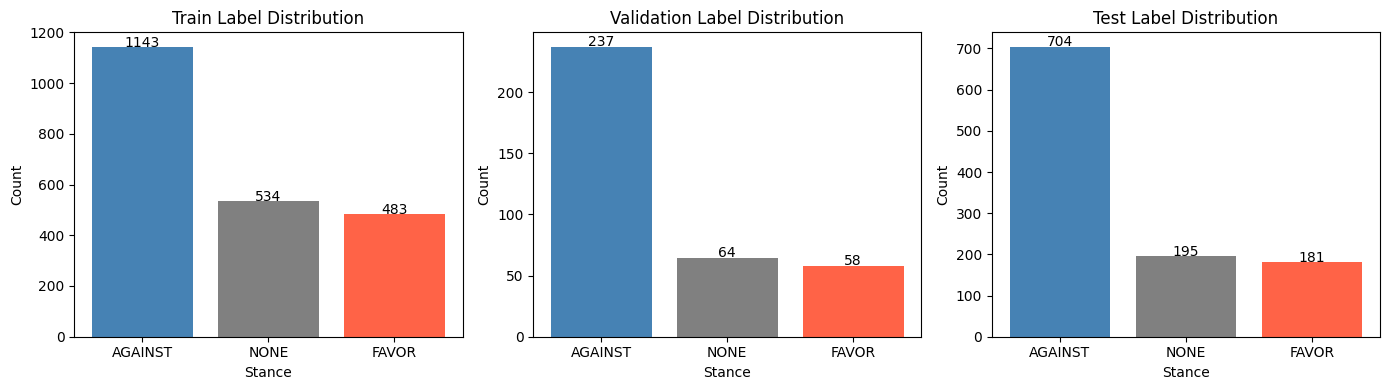

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
splits = {'Train': train_df, 'Validation': val_df, 'Test': test_df}

for ax, (name, df) in zip(axes, splits.items()):
    counts = df['Stance'].value_counts()
    ax.bar(counts.index, counts.values, color=['steelblue', 'gray', 'tomato'])
    ax.set_title(f'{name} Label Distribution')
    ax.set_xlabel('Stance')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 1, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

#### **2.2. Target Distribution**

Unique targets in train:
Target
Hillary Clinton             591
Feminist Movement           569
Legalization of Abortion    561
Atheism                     439
Name: count, dtype: int64


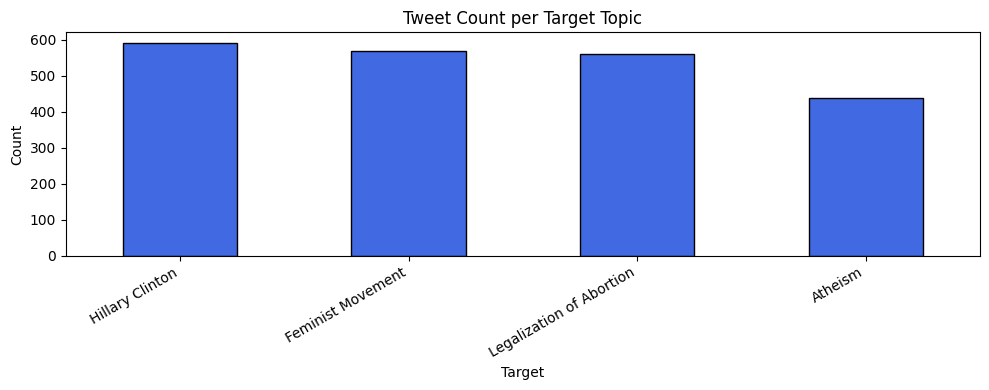

In [12]:
print("Unique targets in train:")
print(train_df['Target'].value_counts())

plt.figure(figsize=(10, 4))
train_df['Target'].value_counts().plot(kind='bar', color='royalblue', edgecolor='black')
plt.title('Tweet Count per Target Topic')
plt.xlabel('Target')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## **3. Preprocess Data**

#### **3.1. Text Cleaning** 

In [ ]:
def clean_text(text):
    text = re.sub(r'#?semst\b', '', text, flags=re.IGNORECASE)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip().lower()
    return text

for df in [train_df, val_df, test_df]:
    df['Tweet'] = df['Tweet'].apply(clean_text)

print("Sample cleaned tweet:")
print(train_df['Tweet'].iloc[0])

Sample cleaned tweet:
dear lord thank u for all of ur blessings forgive my sins lord give me strength and energy for this busy day ahead #blessed #hope


#### **3.4. Target-Aware Input Construction** 

In [18]:
""""Concatenate target + [SEP] + tweet for better context, 
relationship between the text and its target topic, not just the tweet alone."""
for df in [train_df, val_df, test_df]:
    df['input_text'] = df['Target'] + ' [SEP] ' + df['Tweet']

print("Sample input text:")
print(train_df['input_text'].iloc[0])
print("Sample label:")
print(train_df['label'].iloc[0])

Sample input text:
Atheism [SEP] dear lord thank u for all of ur blessings forgive my sins lord give me strength and energy for this busy day ahead #blessed #hope
Sample label:
2


## **4. Visualisations**

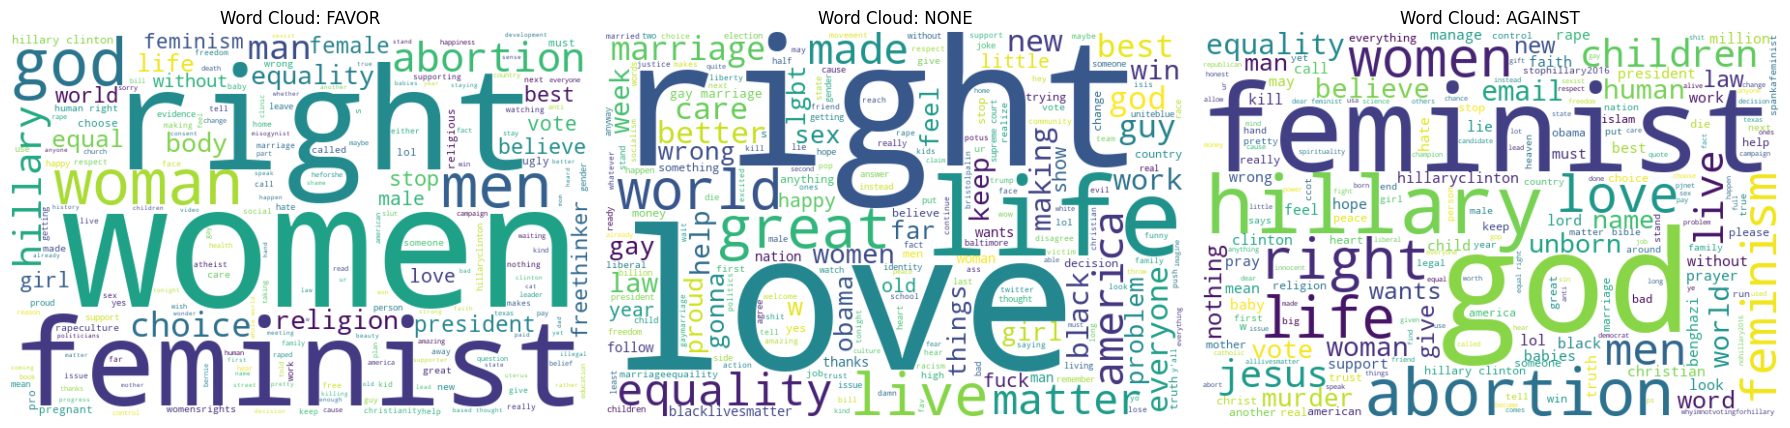

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
stance_labels = ['FAVOR', 'NONE', 'AGAINST']
stop_words = STOPWORDS.union({
    'semst', 'http', 'https', 'rt', 'amp', 
    'one', 'now', 'get', 'go', 'u', 'im', 
    'dont', 'thing', 'people', 'like', 'know', 
    'time', 'see', 'good', 'day', 'want', 'need', 
    'make', 'think', 'will', 'tcot', 'lovewins',
    'baltimoreriots', 'scotusmarriage', 'scotus',
    'wakeupamerica', 'prolifeyouth', 'gamergate',
    'yesallwomen', 'obamacare',
    'still', 'even', 'never', 'always', 'every',
    'much', 'many', 'back', 'say', 'said',
    'come', 'take', 'let', 'us', 'well',
    'way', 'today', 'got', 'going', 'thank'
    })

for ax, stance in zip(axes, stance_labels):
    text = ' '.join(train_df[train_df['Stance'] == stance]['Tweet'])
    wc = WordCloud(width=600, height=400, background_color='white', stopwords=stop_words).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Word Cloud: {stance}')
    ax.axis('off')

plt.tight_layout()
plt.show()